# EDA for Physiological Signals and Annotations

This notebook explores the Kaggle PhysioNet dataset, demographics, EDF signals, CAISR annotations, and human annotations.

In [1]:
import os
os.chdir("/Users/samanthagoncalves/projects/physionet-sleep-cognition")

In [2]:
import os
import glob
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from sklearn.metrics import cohen_kappa_score
import warnings

warnings.filterwarnings('ignore')

# Setup paths
BASE_DIR = "data/kaggle_raw/training_set"
FIGURES_DIR = "notebooks/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Shape: (622, 14)
Columns: ['SiteID', 'BDSPPatientID', 'CreationTime', 'BidsFolder', 'SessionID', 'Age', 'Sex', 'Race', 'Ethnicity', 'BMI', 'Time_to_Event', 'Cognitive_Impairment', 'Last_Known_Visit_Date', 'Time_to_Last_Visit']

Cognitive_Impairment Distribution:
shape: (2, 3)
┌──────────────────────┬───────┬────────────┐
│ Cognitive_Impairment ┆ count ┆ percentage │
│ ---                  ┆ ---   ┆ ---        │
│ bool                 ┆ u32   ┆ u32        │
╞══════════════════════╪═══════╪════════════╡
│ false                ┆ 311   ┆ 31100      │
│ true                 ┆ 311   ┆ 31100      │
└──────────────────────┴───────┴────────────┘


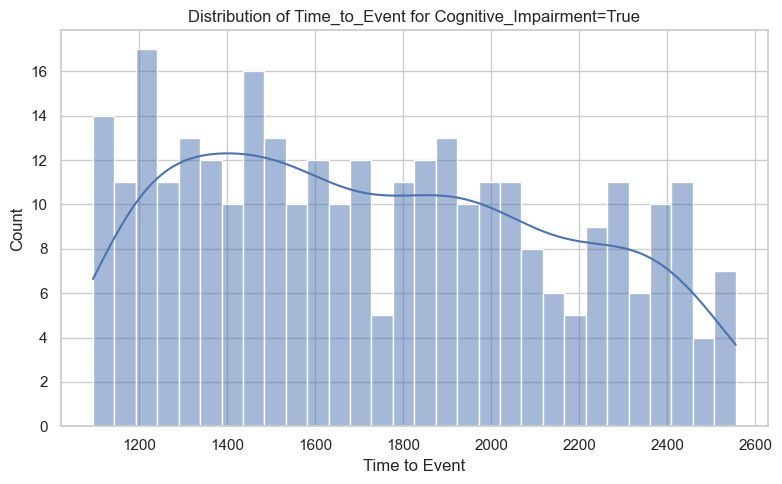


Site Distribution:
shape: (3, 2)
┌────────┬───────┐
│ SiteID ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ I0002  ┆ 36    │
│ I0006  ┆ 102   │
│ S0001  ┆ 484   │
└────────┴───────┘


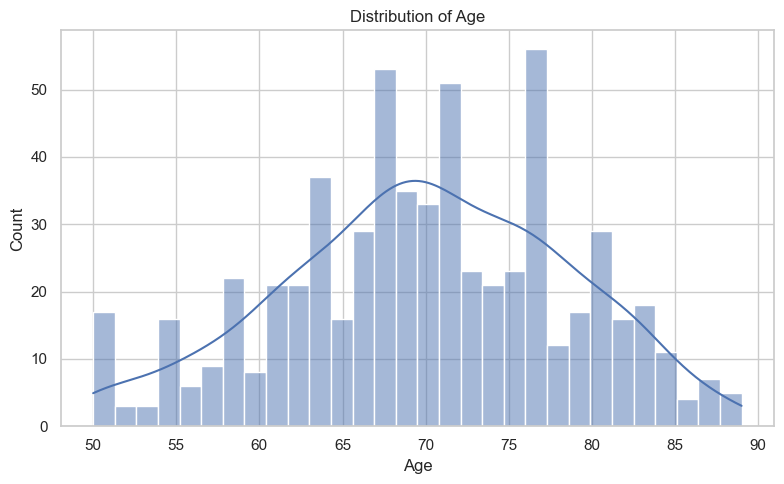


Sex Distribution:
shape: (2, 2)
┌────────┬───────┐
│ Sex    ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ Male   ┆ 358   │
│ Female ┆ 264   │
└────────┴───────┘


In [3]:
# 1. Load demographics data
demo_path = os.path.join(BASE_DIR, "demographics.csv")
df = pl.read_csv(demo_path)

print("Shape:", df.shape)
print("Columns:", df.columns)

# Cognitive_Impairment distribution (counts and %)
ci_dist = df['Cognitive_Impairment'].value_counts().sort('Cognitive_Impairment')
ci_dist_pct = ci_dist.with_columns(pl.col('count').alias('percentage') * 100)
print("\nCognitive_Impairment Distribution:")
print(ci_dist_pct)

# Time_to_Event distribution for True cases
true_mask = df['Cognitive_Impairment'] == True
time_true = df.filter(true_mask)['Time_to_Event'].to_numpy()

plt.figure(figsize=(8, 5))
sns.histplot(time_true, bins=30, kde=True)
plt.title('Distribution of Time_to_Event for Cognitive_Impairment=True')
plt.xlabel('Time to Event')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'time_to_event_true.png'))
plt.show()

# Site distribution
print("\nSite Distribution:")
print(df['SiteID'].value_counts())

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'age_distribution.png'))
plt.show()

# Sex distribution
print("\nSex Distribution:")
print(df['Sex'].value_counts())